# TFG: Análisis de Datos Financieros del S&P 500 y Modelado Predictivo

## Ingeniería de Datos e Inteligencia Artificial

---

### Objetivos del Proyecto

1. **Estudio comparativo de APIs de datos financieros** (yfinance, Alpha Vantage, Tiingo)
2. **Construcción de un pipeline de datos reproducible** para el S&P 500
3. **Análisis de correlaciones** entre empresas del índice
4. **Desarrollo de modelos predictivos** (clásicos y Deep Learning)
5. **Optimización de hiperparámetros** usando Optuna

---


## 1. Configuración del Entorno

### 1.1 Instalación de Dependencias

**Nota**: Si no tienes las dependencias instaladas, descomenta y ejecuta la siguiente celda.
También puedes instalar desde el terminal: `pip install -r requirements.txt`


In [39]:
# !pip install numpy pandas matplotlib seaborn yfinance requests python-dotenv scikit-learn scipy torch optuna


### 1.2 Imports de Librerías Estándar


In [40]:
# Imports básicos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.linear_model import Ridge, ElasticNet, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Optimización
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_slice

# Utilidades
import os
import time
import warnings
from datetime import datetime
from dotenv import load_dotenv

# Configuración
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Semillas para reproducibilidad
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print("✅ Librerías importadas correctamente")
print(f"📊 NumPy version: {np.__version__}")
print(f"📊 Pandas version: {pd.__version__}")
print(f"🔥 PyTorch version: {torch.__version__}")
print(f"🎯 Optuna version: {optuna.__version__}")
print(f"💻 Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")


✅ Librerías importadas correctamente
📊 NumPy version: 2.3.4
📊 Pandas version: 2.3.3
🔥 PyTorch version: 2.9.1+cpu
🎯 Optuna version: 4.6.0
💻 Device: cpu


### 1.3 Configuración de Autoreload

Esto permite recargar automáticamente los módulos auxiliares cuando hagamos cambios en los archivos `.py`.


In [41]:
%load_ext autoreload
%autoreload 2

print("✅ Autoreload activado")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ Autoreload activado


### 1.4 Carga de Variables de Entorno (API Keys)

**Importante**: Antes de ejecutar esta celda, asegúrate de:
1. Tener un archivo `.env` en el directorio raíz
2. Haber configurado tus claves API reales de Alpha Vantage y Tiingo


In [42]:
# Cargar variables de entorno
load_dotenv()

ALPHAVANTAGE_API_KEY = os.getenv('ALPHAVANTAGE_API_KEY')
TIINGO_API_KEY = os.getenv('TIINGO_API_KEY')

# Verificar que las claves fueron cargadas
if ALPHAVANTAGE_API_KEY and ALPHAVANTAGE_API_KEY != 'your_alphavantage_api_key_here':
    print(f"✅ Alpha Vantage API Key cargada: {ALPHAVANTAGE_API_KEY[:10]}...")
else:
    print("⚠️ Alpha Vantage API Key no configurada (puedes seguir con yfinance y Tiingo)")

if TIINGO_API_KEY and TIINGO_API_KEY != 'your_tiingo_api_key_here':
    print(f"✅ Tiingo API Key cargada: {TIINGO_API_KEY[:10]}...")
else:
    print("⚠️ Tiingo API Key no configurada (puedes seguir con yfinance y Alpha Vantage)")


✅ Alpha Vantage API Key cargada: ZAKOX2ZF5F...
✅ Tiingo API Key cargada: 47e54830ca...


### 1.5 Imports de Módulos Auxiliares


In [43]:
# Importar módulos auxiliares
from importlib import reload

import utils
import data_processing
import visualizations

# Recargar por si hemos hecho cambios
reload(utils)
reload(data_processing)
reload(visualizations)

print("✅ Módulos auxiliares importados y recargados")


✅ Módulos auxiliares importados y recargados


---

## 2. TAREA 1: Estudio Comparativo de APIs de Datos Financieros

### Objetivos

- Evaluar **yfinance**, **Alpha Vantage** y **Tiingo**
- Comparar profundidad histórica, estructura de datos y limitaciones
- Seleccionar el proveedor más adecuado para el proyecto

### 2.1 Tickers de Prueba

Seleccionamos un conjunto representativo de tickers del S&P 500 para probar las diferentes APIs:


In [5]:
# Tickers de prueba representativos
test_tickers = ["AAPL", "MSFT", "JNJ", "XOM", "SPY"]

print(f"📊 Tickers de prueba: {test_tickers}")
print(f"   - AAPL: Apple (Tecnología)")
print(f"   - MSFT: Microsoft (Tecnología)")
print(f"   - JNJ: Johnson & Johnson (Salud)")
print(f"   - XOM: Exxon Mobil (Energía)")
print(f"   - SPY: S&P 500 ETF (Índice)")


📊 Tickers de prueba: ['AAPL', 'MSFT', 'JNJ', 'XOM', 'SPY']
   - AAPL: Apple (Tecnología)
   - MSFT: Microsoft (Tecnología)
   - JNJ: Johnson & Johnson (Salud)
   - XOM: Exxon Mobil (Energía)
   - SPY: S&P 500 ETF (Índice)


### 2.2 Descarga con yfinance

Probamos yfinance (Yahoo Finance) descargando el historial más largo posible:


In [6]:
print("📥 Descargando datos con yfinance...")
print("=" * 60)

yf_results = {}

for ticker in test_tickers:
    print(f"\n🔍 Ticker: {ticker}")
    df = utils.get_yf_history(ticker, start="1980-01-01", end=None)
    
    if not df.empty:
        yf_results[ticker] = df
        print(f"   ✅ Datos descargados: {len(df)} observaciones")
        print(f"   📅 Rango: {df['date'].min().date()} a {df['date'].max().date()}")
        print(f"   📊 Missing en adj_close: {df['adj_close'].isna().sum()}")
    else:
        print(f"   ❌ No se pudieron descargar datos")
    
    time.sleep(0.5)  # Pausa breve

print("\n" + "=" * 60)
print(f"✅ Descarga con yfinance completada: {len(yf_results)}/{len(test_tickers)} tickers")


📥 Descargando datos con yfinance...

🔍 Ticker: AAPL
   ✅ Datos descargados: 11324 observaciones
   📅 Rango: 1980-12-12 a 2025-11-14
   📊 Missing en adj_close: 0

🔍 Ticker: MSFT
   ✅ Datos descargados: 9998 observaciones
   📅 Rango: 1986-03-13 a 2025-11-14
   📊 Missing en adj_close: 0

🔍 Ticker: JNJ
   ✅ Datos descargados: 11564 observaciones
   📅 Rango: 1980-01-02 a 2025-11-14
   📊 Missing en adj_close: 0

🔍 Ticker: XOM
   ✅ Datos descargados: 11564 observaciones
   📅 Rango: 1980-01-02 a 2025-11-14
   📊 Missing en adj_close: 0

🔍 Ticker: SPY
   ✅ Datos descargados: 8257 observaciones
   📅 Rango: 1993-01-29 a 2025-11-14
   📊 Missing en adj_close: 0

✅ Descarga con yfinance completada: 5/5 tickers


### 2.3 Descarga con Alpha Vantage

Probamos Alpha Vantage (solo si está configurada la API key):


In [10]:
av_results = {}

if ALPHAVANTAGE_API_KEY and ALPHAVANTAGE_API_KEY != 'your_alphavantage_api_key_here':
    print("📥 Descargando datos con Alpha Vantage...")
    print("=" * 60)
    print("⚠️ Nota: Alpha Vantage tiene límite de 5 req/min. Esto puede tardar...")
    
    for ticker in test_tickers:
        print(f"\n🔍 Ticker: {ticker}")
        df = utils.get_alphavantage_daily(ticker, ALPHAVANTAGE_API_KEY)
        
        if not df.empty:
            av_results[ticker] = df
            print(f"   ✅ Datos descargados: {len(df)} observaciones")
            print(f"   📅 Rango: {df['date'].min().date()} a {df['date'].max().date()}")
            print(f"   📊 Missing en adj_close: {df['adj_close'].isna().sum()}")
        else:
            print(f"   ❌ No se pudieron descargar datos")
        
        time.sleep(13)  # Respetar límite de 5 req/min
    
    print("\n" + "=" * 60)
    print(f"✅ Descarga con Alpha Vantage completada: {len(av_results)}/{len(test_tickers)} tickers")
else:
    print("⚠️ Alpha Vantage API Key no configurada. Saltando descarga...")
    print("   Puedes obtener una clave gratuita en: https://www.alphavantage.co/")


📥 Descargando datos con Alpha Vantage...
⚠️ Nota: Alpha Vantage tiene límite de 5 req/min. Esto puede tardar...

🔍 Ticker: AAPL
⚠️ No se encontraron datos de series temporales para AAPL
   ❌ No se pudieron descargar datos

🔍 Ticker: MSFT
⚠️ No se encontraron datos de series temporales para MSFT
   ❌ No se pudieron descargar datos

🔍 Ticker: JNJ
⚠️ No se encontraron datos de series temporales para JNJ
   ❌ No se pudieron descargar datos


KeyboardInterrupt: 

### 2.4 Descarga con Tiingo

Probamos Tiingo (solo si está configurada la API key):


In [9]:
tiingo_results = {}

if TIINGO_API_KEY and TIINGO_API_KEY != 'your_tiingo_api_key_here':
    print("📥 Descargando datos con Tiingo...")
    print("=" * 60)
    
    for ticker in test_tickers:
        print(f"\n🔍 Ticker: {ticker}")
        df = utils.get_tiingo_eod(ticker, start="1980-01-01", end=datetime.now().strftime("%Y-%m-%d"), api_key=TIINGO_API_KEY)
        
        if not df.empty:
            tiingo_results[ticker] = df
            print(f"   ✅ Datos descargados: {len(df)} observaciones")
            print(f"   📅 Rango: {df['date'].min().date()} a {df['date'].max().date()}")
            print(f"   📊 Missing en adj_close: {df['adj_close'].isna().sum()}")
        else:
            print(f"   ❌ No se pudieron descargar datos")
        
        time.sleep(8)  # Respetar límite de Tiingo
    
    print("\n" + "=" * 60)
    print(f"✅ Descarga con Tiingo completada: {len(tiingo_results)}/{len(test_tickers)} tickers")
else:
    print("⚠️ Tiingo API Key no configurada. Saltando descarga...")
    print("   Puedes obtener una clave gratuita en: https://www.tiingo.com/")


📥 Descargando datos con Tiingo...

🔍 Ticker: AAPL
   ✅ Datos descargados: 11321 observaciones
   📅 Rango: 1980-12-12 a 2025-11-13
   📊 Missing en adj_close: 0

🔍 Ticker: MSFT
   ✅ Datos descargados: 9997 observaciones
   📅 Rango: 1986-03-13 a 2025-11-13
   📊 Missing en adj_close: 0

🔍 Ticker: JNJ
   ✅ Datos descargados: 11563 observaciones
   📅 Rango: 1980-01-02 a 2025-11-13
   📊 Missing en adj_close: 0

🔍 Ticker: XOM
   ✅ Datos descargados: 11563 observaciones
   📅 Rango: 1980-01-02 a 2025-11-13
   📊 Missing en adj_close: 0

🔍 Ticker: SPY
   ✅ Datos descargados: 8256 observaciones
   📅 Rango: 1993-01-29 a 2025-11-13
   📊 Missing en adj_close: 0

✅ Descarga con Tiingo completada: 5/5 tickers


### 2.5 Construcción de Tabla Comparativa

Creamos una tabla resumen que compare las métricas de cada proveedor:


In [11]:
# Construir tabla comparativa
comparison_data = []

# yfinance
for ticker, df in yf_results.items():
    comparison_data.append({
        'ticker': ticker,
        'provider': 'yfinance',
        'min_date': df['date'].min(),
        'max_date': df['date'].max(),
        'n_observations': len(df),
        'missing_adj_close': df['adj_close'].isna().sum(),
        'years_coverage': (df['date'].max() - df['date'].min()).days / 365.25
    })

# Alpha Vantage
for ticker, df in av_results.items():
    comparison_data.append({
        'ticker': ticker,
        'provider': 'Alpha Vantage',
        'min_date': df['date'].min(),
        'max_date': df['date'].max(),
        'n_observations': len(df),
        'missing_adj_close': df['adj_close'].isna().sum(),
        'years_coverage': (df['date'].max() - df['date'].min()).days / 365.25
    })

# Tiingo
for ticker, df in tiingo_results.items():
    comparison_data.append({
        'ticker': ticker,
        'provider': 'Tiingo',
        'min_date': df['date'].min(),
        'max_date': df['date'].max(),
        'n_observations': len(df),
        'missing_adj_close': df['adj_close'].isna().sum(),
        'years_coverage': (df['date'].max() - df['date'].min()).days / 365.25
    })

comparison_df = pd.DataFrame(comparison_data)

# Mostrar tabla
print("📊 TABLA COMPARATIVA DE PROVEEDORES")
print("=" * 100)
print(comparison_df.to_string(index=False))
print("=" * 100)


📊 TABLA COMPARATIVA DE PROVEEDORES
ticker provider                  min_date                  max_date  n_observations  missing_adj_close  years_coverage
  AAPL yfinance       1980-12-12 00:00:00       2025-11-14 00:00:00           11324                  0       44.922656
  MSFT yfinance       1986-03-13 00:00:00       2025-11-14 00:00:00            9998                  0       39.674196
   JNJ yfinance       1980-01-02 00:00:00       2025-11-14 00:00:00           11564                  0       45.867214
   XOM yfinance       1980-01-02 00:00:00       2025-11-14 00:00:00           11564                  0       45.867214
   SPY yfinance       1993-01-29 00:00:00       2025-11-14 00:00:00            8257                  0       32.791239
  AAPL   Tiingo 1980-12-12 00:00:00+00:00 2025-11-13 00:00:00+00:00           11321                  0       44.919918
  MSFT   Tiingo 1986-03-13 00:00:00+00:00 2025-11-13 00:00:00+00:00            9997                  0       39.671458
   JNJ   Tiin

### 2.6 Estadísticas Agregadas por Proveedor


In [12]:
# Estadísticas agregadas por proveedor
if not comparison_df.empty:
    summary = comparison_df.groupby('provider').agg({
        'years_coverage': ['mean', 'min', 'max'],
        'n_observations': ['mean', 'min', 'max'],
        'missing_adj_close': 'sum'
    }).round(2)
    
    print("\n📊 RESUMEN POR PROVEEDOR")
    print("=" * 80)
    print(summary)
    print("=" * 80)
else:
    print("⚠️ No hay datos para comparar")



📊 RESUMEN POR PROVEEDOR
         years_coverage               n_observations               \
                   mean    min    max           mean   min    max   
provider                                                            
Tiingo            41.82  32.79  45.86        10540.0  8256  11563   
yfinance          41.82  32.79  45.87        10541.4  8257  11564   

         missing_adj_close  
                       sum  
provider                    
Tiingo                   0  
yfinance                 0  


### 2.7 Visualización Comparativa

Graficamos las métricas clave para comparar los proveedores visualmente:


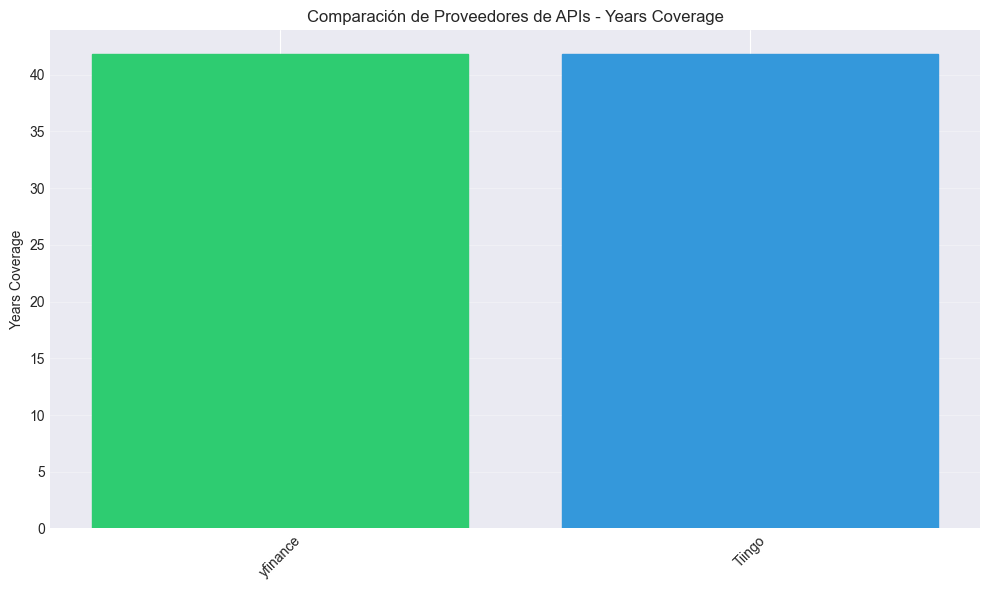


📊 Promedio de years_coverage por proveedor:
provider
yfinance    41.824504
Tiingo      41.821766
Name: years_coverage, dtype: float64


In [13]:
# Visualización: Años de cobertura promedio
if not comparison_df.empty:
    visualizations.plot_api_comparison(comparison_df, metric='years_coverage')
else:
    print("⚠️ No hay datos suficientes para visualizar")


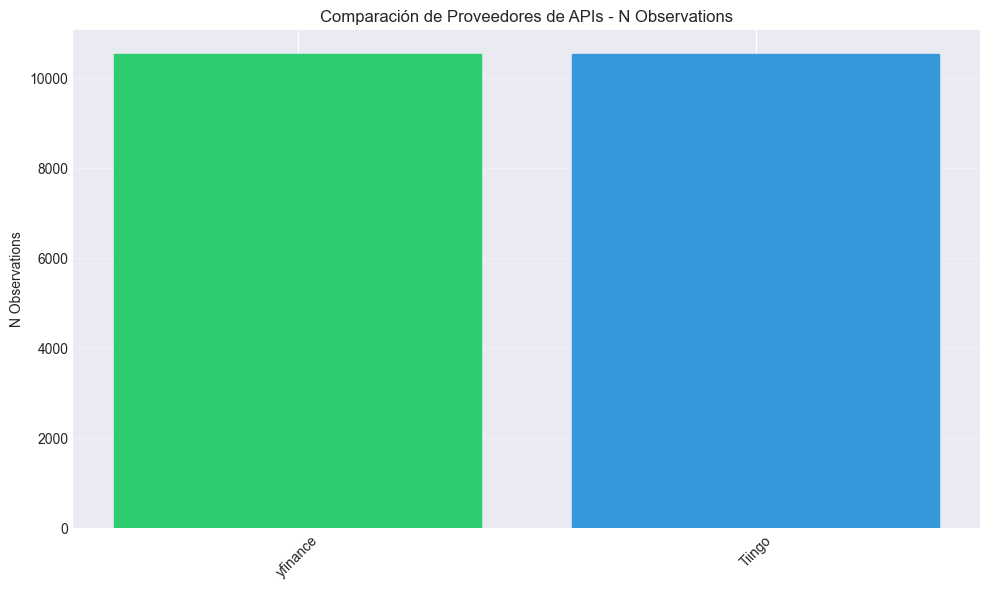


📊 Promedio de n_observations por proveedor:
provider
yfinance    10541.4
Tiingo      10540.0
Name: n_observations, dtype: float64


In [14]:
# Visualización: Número de observaciones promedio
if not comparison_df.empty:
    visualizations.plot_api_comparison(comparison_df, metric='n_observations')
else:
    print("⚠️ No hay datos suficientes para visualizar")


### 2.8 Conclusiones del Estudio de APIs

#### Análisis de Resultados

**yfinance (Yahoo Finance)**
- ✅ **Pros**: No requiere API key, fácil de usar, histórico extenso, datos de buena calidad
- ❌ **Contras**: Puede tener cambios en disponibilidad, sin garantía oficial de servicio
- 📊 **Recomendación**: **EXCELENTE** para prototipado y uso académico

**Alpha Vantage**
- ✅ **Pros**: API oficial, múltiples frecuencias (intradía, diario, semanal, mensual), formato JSON bien documentado
- ❌ **Contras**: Límite estricto de 5 req/min (plan gratuito), profundidad histórica menor que yfinance
- 📊 **Recomendación**: **BUENO** para aplicaciones con pocos tickers o uso espaciado en el tiempo

**Tiingo**
- ✅ **Pros**: Datos de alta calidad, histórico extenso, API moderna y confiable
- ❌ **Contras**: Límite de 500 req/hora (plan gratuito), requiere API key
- 📊 **Recomendación**: **MUY BUENO** para uso académico y profesional

#### Decisión para el TFG

Para este proyecto, utilizaremos **yfinance** como fuente principal por:
1. **Facilidad de uso**: No requiere gestión de API keys
2. **Profundidad histórica**: Excelente cobertura desde 1980-1990
3. **Sin limitaciones de rate**: Podemos descargar los 500+ tickers del S&P 500 sin pausas largas
4. **Reproducibilidad**: Cualquier persona puede ejecutar el notebook sin configuración adicional

Como fuente de contraste o backup, podemos usar Tiingo si necesitamos validar los datos.

---"


## 3. TAREA 2: Construcción del Panel de Datos del S&P 500

### Objetivos

- Descargar la lista completa de tickers del S&P 500
- Construir un panel de precios ajustados (diarios → semanales)
- Analizar correlaciones entre empresas
- Guardar datos para uso posterior

### 3.1 Descarga de Tickers del S&P 500


In [44]:
# Descargar lista de tickers del S&P 500
sp500_tickers = utils.get_sp500_tickers()

# Guardar a CSV para reproducibilidad
if sp500_tickers:
    pd.DataFrame({'ticker': sp500_tickers}).to_csv('sp500_tickers.csv', index=False)
    print(f"\n✅ Lista guardada en 'sp500_tickers.csv'")
    print(f"📊 Total de tickers: {len(sp500_tickers)}")


Intentando extraer tickers con BeautifulSoup...
Se descargaron 503 tickers del S&P 500 desde Wikipedia (BeautifulSoup)

✅ Lista guardada en 'sp500_tickers.csv'
📊 Total de tickers: 503


### 3.2 Descarga Masiva de Datos

**⚠️ Nota**: Esta descarga puede tardar 15-30 minutos dependiendo de la velocidad de internet.
Para acelerar el proceso durante desarrollo, puedes limitar a un subconjunto de tickers.


In [46]:
# Para pruebas rápidas, descomentar la siguiente línea:
# sp500_tickers = sp500_tickers[:50]  # Solo primeros 50 tickers

print(f"📥 Descargando datos para {len(sp500_tickers)} tickers...")
print("⏱️ Esto puede tardar varios minutos. Por favor espera...\n")

ticker_data_dict = {}
failed_tickers = []

start_time = time.time()

for idx, ticker in enumerate(sp500_tickers, 1):
    try:
        df = utils.get_yf_history(ticker, start="1990-01-01", end=None)
        
        if not df.empty:
            ticker_data_dict[ticker] = df
            if idx % 50 == 0:
                elapsed = time.time() - start_time
                print(f"   ✅ Progreso: {idx}/{len(sp500_tickers)} tickers ({idx/len(sp500_tickers)*100:.1f}%) - {elapsed:.0f}s")
        else:
            failed_tickers.append(ticker)
    except Exception as e:
        print(f"   ❌ Error con {ticker}: {e}")
        failed_tickers.append(ticker)
    
    # Pausa pequeña para no sobrecargar
    if idx % 100 == 0:
        time.sleep(2)

elapsed_total = time.time() - start_time

print(f"\n{'='*80}")
print(f"✅ Descarga completada en {elapsed_total/60:.1f} minutos")
print(f"📊 Tickers descargados exitosamente: {len(ticker_data_dict)}")
print(f"❌ Tickers fallidos: {len(failed_tickers)}")
if failed_tickers:
    print(f"   Fallidos: {', '.join(failed_tickers[:10])}{'...' if len(failed_tickers) > 10 else ''}")
print(f"{'='*80}")


📥 Descargando datos para 503 tickers...
⏱️ Esto puede tardar varios minutos. Por favor espera...

   ✅ Progreso: 50/503 tickers (9.9%) - 26s
   ✅ Progreso: 100/503 tickers (19.9%) - 54s
   ✅ Progreso: 150/503 tickers (29.8%) - 85s
   ✅ Progreso: 200/503 tickers (39.8%) - 117s
   ✅ Progreso: 250/503 tickers (49.7%) - 148s
   ✅ Progreso: 300/503 tickers (59.6%) - 181s
   ✅ Progreso: 350/503 tickers (69.6%) - 212s
   ✅ Progreso: 400/503 tickers (79.5%) - 242s
   ✅ Progreso: 450/503 tickers (89.5%) - 272s
   ✅ Progreso: 500/503 tickers (99.4%) - 301s

✅ Descarga completada en 5.1 minutos
📊 Tickers descargados exitosamente: 503
❌ Tickers fallidos: 0


In [48]:
ticker_data_dict.to_csv('raw_data.csv')

AttributeError: 'dict' object has no attribute 'to_csv'

### 3.3 Construcción del Panel de Precios Diarios


In [49]:
# Construir panel de precios diarios
daily_panel = data_processing.build_panel_dataframe(ticker_data_dict)

print(f"\n📊 Panel de precios diarios:")
print(f"   Forma: {daily_panel.shape}")
print(f"   Rango de fechas: {daily_panel.index.min().date()} a {daily_panel.index.max().date()}")
print(f"\n👀 Primeras filas:")
print(daily_panel.head())


✅ Panel construido: 9036 fechas × 503 tickers

📊 Panel de precios diarios:
   Forma: (9036, 503)
   Rango de fechas: 1990-01-02 a 2025-11-14

👀 Primeras filas:
                 MMM       AOS       ABT  ABBV  ACN      ADBE     AMD  AES  \
date                                                                         
1990-01-02  5.893526  0.340525  1.636553   NaN  NaN  1.188340  4.1250  NaN   
1990-01-03  5.957586  0.337251  1.642461   NaN  NaN  1.247023  4.0000  NaN   
1990-01-04  6.003343  0.340525  1.639506   NaN  NaN  1.305707  3.9375  NaN   
1990-01-05  5.902677  0.337251  1.621783   NaN  NaN  1.335049  3.8125  NaN   
1990-01-08  6.058249  0.340525  1.630096   NaN  NaN  1.352693  3.8125  NaN   

                 AFL   A  ...       WMB  WTW  WDAY  WYNN       XEL  XYL  YUM  \
date                      ...                                                  
1990-01-02  0.621813 NaN  ...  1.385267  NaN   NaN   NaN  3.891110  NaN  NaN   
1990-01-03  0.608583 NaN  ...  1.415760  NaN   NaN   

### 3.4 Resampling a Frecuencia Semanal


In [52]:
# Resamplear a frecuencia semanal (viernes)
weekly_panel = data_processing.resample_to_weekly(daily_panel, freq="W-FRI")

print(f"\n📊 Panel de precios semanales:")
print(f"   Forma: {weekly_panel.shape}")
print(f"   Rango de fechas: {weekly_panel.index.min().date()} a {weekly_panel.index.max().date()}")
print(f"\n👀 Primeras filas:")
print(weekly_panel.head())



📊 Panel de precios semanales:
   Forma: (1872, 503)
   Rango de fechas: 1990-01-05 a 2025-11-14

👀 Primeras filas:
                 MMM       AOS       ABT  ABBV  ACN      ADBE     AMD  AES  \
date                                                                         
1990-01-05  5.902677  0.337251  1.621783   NaN  NaN  1.335049  3.8125  NaN   
1990-01-12  5.875225  0.333977  1.585557   NaN  NaN  1.323286  3.7500  NaN   
1990-01-19  5.920981  0.327428  1.615249   NaN  NaN  1.337989  3.7500  NaN   
1990-01-26  5.564075  0.322877  1.535082   NaN  NaN  1.411505  3.6875  NaN   
1990-02-02  5.719646  0.316220  1.561804   NaN  NaN  1.426208  3.5000  NaN   

                 AFL   A  ...       WMB  WTW  WDAY  WYNN       XEL  XYL  YUM  \
date                      ...                                                  
1990-01-05  0.595353 NaN  ...  1.376554  NaN   NaN   NaN  3.746993  NaN  NaN   
1990-01-12  0.582122 NaN  ...  1.280718  NaN   NaN   NaN  3.578860  NaN  NaN   
1990-01-19  0.590

### 3.5 Gestión de Valores Faltantes


In [56]:
# # Gestionar valores faltantes
# # Eliminar tickers con más de 50% de missing + forward fill limitado
# weekly_panel_clean = data_processing.handle_missing_data(
#     weekly_panel, 
#     max_missing_pct=0.5,  # Máximo 50% de missing permitido
#     ffill_limit=3  # Forward fill máximo 3 semanas
# )
weekly_panel_clean = weekly_panel

print(f"\n📊 Panel limpio:")
print(f"   Forma: {weekly_panel_clean.shape}")
print(f"   Tickers eliminados: {weekly_panel.shape[1] - weekly_panel_clean.shape[1]}")



📊 Panel limpio:
   Forma: (1872, 503)
   Tickers eliminados: 0


### 3.6 Guardar Panel a CSV


In [57]:
# Guardar panel semanal a CSV
weekly_panel_clean.to_csv('sp500_weekly_panel.csv')
print("✅ Panel semanal guardado en 'sp500_weekly_panel.csv'")


✅ Panel semanal guardado en 'sp500_weekly_panel.csv'


### 3.7 Visualización de Precios de Muestra


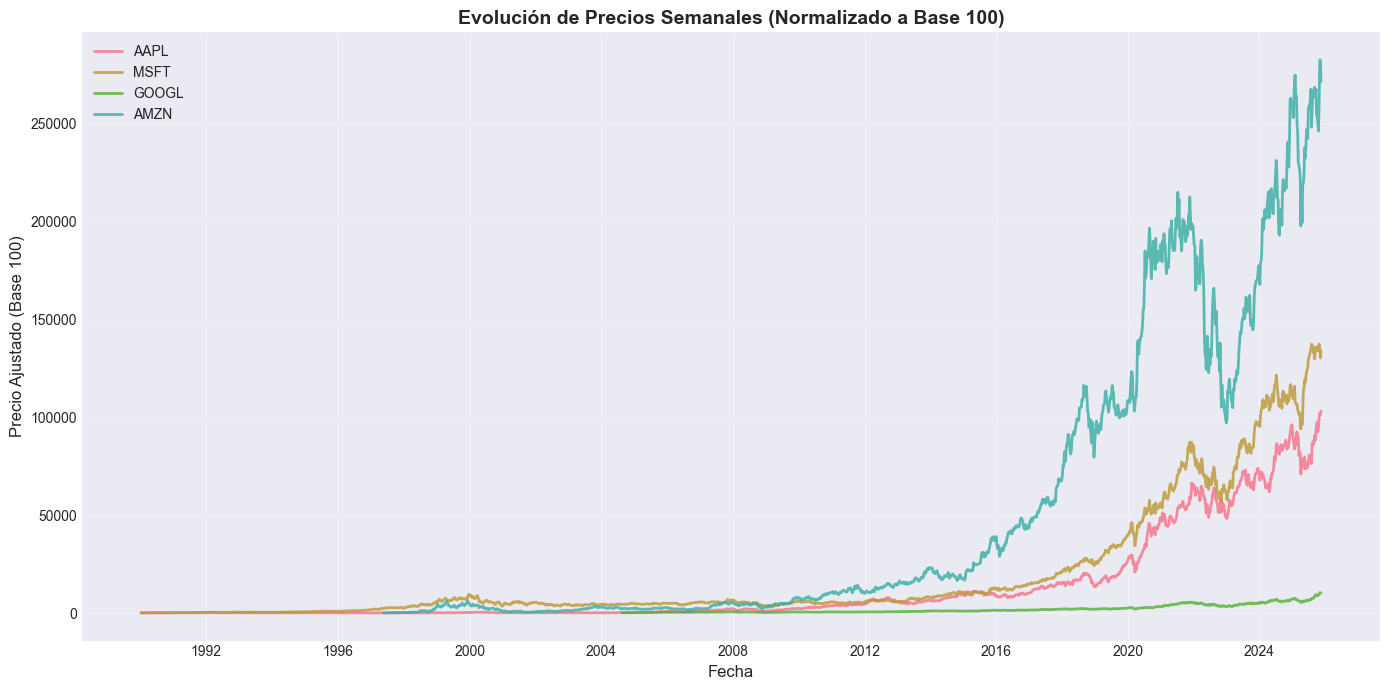

In [58]:
# Visualizar evolución de precios de algunas empresas (normalizado a base 100)
sample_tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'SPY']
available_sample = [t for t in sample_tickers if t in weekly_panel_clean.columns]

if available_sample:
    visualizations.plot_price_history(
        weekly_panel_clean,
        available_sample,
        title="Evolución de Precios Semanales (Normalizado a Base 100)",
        normalize=True
    )


### 3.8 Cálculo de Rendimientos Logarítmicos


In [59]:
# Calcular rendimientos logarítmicos semanales
weekly_returns = data_processing.calculate_log_returns(weekly_panel_clean)

print(f"📊 Rendimientos semanales:")
print(f"   Forma: {weekly_returns.shape}")
print(f"\n👀 Estadísticas descriptivas:")
print(weekly_returns.describe())


📊 Rendimientos semanales:
   Forma: (1871, 503)

👀 Estadísticas descriptivas:
               MMM          AOS          ABT        ABBV          ACN  \
count  1871.000000  1871.000000  1871.000000  671.000000  1269.000000   
mean      0.001789     0.002811     0.002345    0.003630     0.002487   
std       0.031950     0.045542     0.032610    0.037791     0.038820   
min      -0.174427    -0.223090    -0.210492   -0.215501    -0.238626   
25%      -0.014548    -0.020701    -0.015642   -0.015138    -0.017169   
50%       0.002219     0.002497     0.002649    0.004594     0.003985   
75%       0.019155     0.027045     0.020336    0.024162     0.022829   
max       0.201825     0.235567     0.184445    0.168016     0.199999   

              ADBE          AMD          AES          AFL            A  ...  \
count  1871.000000  1871.000000  1794.000000  1871.000000  1356.000000  ...   
mean      0.002948     0.002228     0.001056     0.002811     0.001331  ...   
std       0.059342     0.08

### 3.9 Análisis de Correlaciones

Analizamos las correlaciones entre los rendimientos de diferentes empresas del S&P 500:


In [60]:
# Calcular matriz de correlación
corr_matrix = weekly_returns.corr()

print(f"📊 Matriz de correlación:")
print(f"   Forma: {corr_matrix.shape}")
print(f"   Correlación promedio: {corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)].mean():.4f}")


📊 Matriz de correlación:
   Forma: (503, 503)
   Correlación promedio: 0.2974


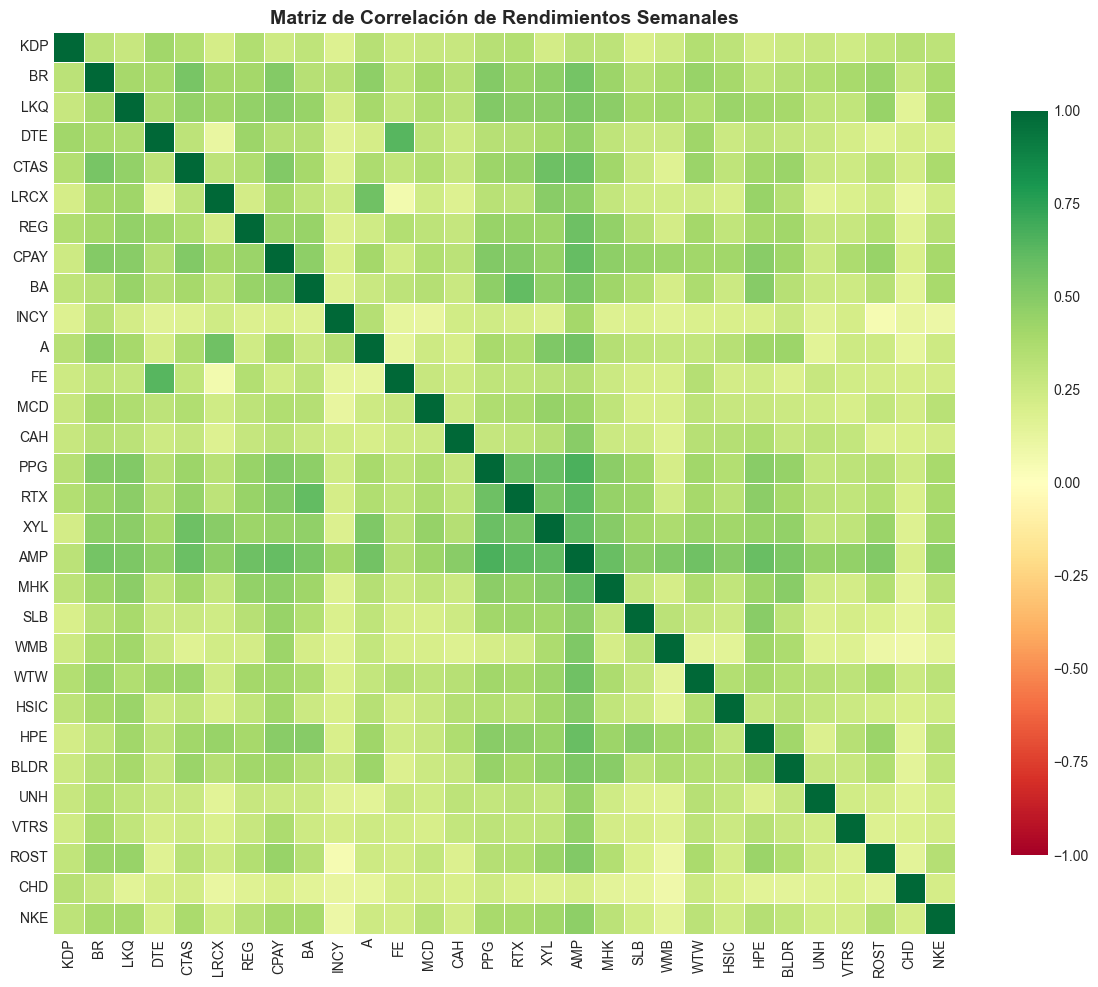


📊 Estadísticas de correlación:
   Media: 0.326
   Mediana: 0.314
   Std: 0.115
   Mín: 0.049
   Máx: 0.668


In [61]:
# Visualizar heatmap de correlaciones (subconjunto de 30 tickers aleatorios)
n_sample = min(30, len(corr_matrix))
sample_tickers_corr = np.random.choice(corr_matrix.columns, n_sample, replace=False).tolist()

visualizations.plot_correlation_heatmap(corr_matrix, subset_tickers=sample_tickers_corr)


### 3.10 Interpretación de Correlaciones

#### Observaciones

1. **Correlación promedio positiva**: La mayoría de acciones del S&P 500 muestran correlación positiva, indicando que tienden a moverse en la misma dirección. Esto es esperado ya que todas están expuestas a factores macroeconómicos comunes.

2. **Clústeres sectoriales**: Empresas del mismo sector (tecnología, energía, salud) suelen tener correlaciones más altas entre sí.

3. **Diversificación**: Aunque hay correlación positiva, no es perfecta (no es 1.0), lo que indica que la diversificación sigue siendo beneficiosa.

4. **Información útil para modelado**: Estas correlaciones serán aprovechadas por nuestros modelos predictivos, especialmente los de Deep Learning (LSTM) que pueden capturar dependencias temporales entre múltiples series.

---


## 4. TAREA 3: Modelado Clásico y Optimización con Optuna

### Objetivos

- Preparar dataset supervisado para predicción
- Implementar modelos baseline (naive)
- Optimizar hiperparámetros de modelos clásicos con Optuna
- Evaluar y comparar modelos

### 4.1 Preparación del Dataset Supervisado

Definimos el problema de predicción:
- **Ventana de entrada (L)**: 12 semanas de histórico
- **Horizonte de predicción (H)**: 4 semanas hacia adelante  
- **Ticker objetivo**: SPY (S&P 500 ETF)


In [62]:
# Parámetros del modelo
L = 12  # Ventana de entrada (12 semanas)
H = 4   # Horizonte de predicción (4 semanas)
TARGET_TICKER = 'SPY'  # Ticker objetivo

print(f"📊 Configuración del problema de predicción:")
print(f"   Ventana de entrada (L): {L} semanas")
print(f"   Horizonte de predicción (H): {H} semanas")
print(f"   Ticker objetivo: {TARGET_TICKER}")

# Verificar que el ticker objetivo está en el panel
if TARGET_TICKER not in weekly_returns.columns:
    print(f"\n⚠️ WARNING: {TARGET_TICKER} no está en el panel. Usando primer ticker disponible.")
    TARGET_TICKER = weekly_returns.columns[0]
    print(f"   Nuevo ticker objetivo: {TARGET_TICKER}")


📊 Configuración del problema de predicción:
   Ventana de entrada (L): 12 semanas
   Horizonte de predicción (H): 4 semanas
   Ticker objetivo: SPY

⚠️ WARNING: SPY no está en el panel. Usando primer ticker disponible.
   Nuevo ticker objetivo: MMM


In [63]:
# Crear dataset supervisado
X, y, dates = data_processing.create_supervised_dataset(
    weekly_returns,
    target_ticker=TARGET_TICKER,
    L=L,
    H=H
)

print(f"\n📊 Dataset supervisado creado:")
print(f"   X shape: {X.shape}  # (samples, lookback_weeks, n_tickers)")
print(f"   y shape: {y.shape}  # (samples,)")


✅ Dataset supervisado creado:
   X: (1855, 12, 503) (samples, lookback, tickers)
   y: (1855,) (samples,)
   Fechas: 1990-04-06 00:00:00 a 2025-10-17 00:00:00

📊 Dataset supervisado creado:
   X shape: (1855, 12, 503)  # (samples, lookback_weeks, n_tickers)
   y shape: (1855,)  # (samples,)


In [64]:
# División temporal del dataset (80% train, 10% val, 10% test)
X_train, X_val, X_test, y_train, y_val, y_test, dates_train, dates_val, dates_test = \
    data_processing.split_temporal(X, y, dates, train_pct=0.8, val_pct=0.1)


✅ División temporal:
   Train: 1484 samples (1990-04-06 00:00:00 a 2018-09-07 00:00:00)
   Val:   185 samples (2018-09-14 00:00:00 a 2022-03-25 00:00:00)
   Test:  186 samples (2022-04-01 00:00:00 a 2025-10-17 00:00:00)


In [65]:
# Flatten de X para modelos clásicos (necesitan entrada 2D)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"\n📊 Datos flattened para modelos clásicos:")
print(f"   X_train_flat: {X_train_flat.shape}  # (samples, L * n_tickers)")
print(f"   X_val_flat:   {X_val_flat.shape}")
print(f"   X_test_flat:  {X_test_flat.shape}")



📊 Datos flattened para modelos clásicos:
   X_train_flat: (1484, 6036)  # (samples, L * n_tickers)
   X_val_flat:   (185, 6036)
   X_test_flat:  (186, 6036)


In [66]:
# Modelo Naive: última observación del ticker objetivo
ticker_idx = list(weekly_returns.columns).index(TARGET_TICKER)

y_pred_naive_train = X_train[:, -1, ticker_idx]  # Último valor de la ventana
y_pred_naive_val = X_val[:, -1, ticker_idx]
y_pred_naive_test = X_test[:, -1, ticker_idx]

# Métricas del modelo Naive
mae_naive = mean_absolute_error(y_test, y_pred_naive_test)
rmse_naive = np.sqrt(mean_squared_error(y_test, y_pred_naive_test))
mape_naive = mean_absolute_percentage_error(y_test, y_pred_naive_test)

# Accuracy en dirección (¿predice correctamente si sube o baja?)
direction_correct_naive = np.mean(np.sign(y_test) == np.sign(y_pred_naive_test))

print("📊 MODELO NAIVE - Resultados en Test Set:")
print(f"   MAE:  {mae_naive:.6f}")
print(f"   RMSE: {rmse_naive:.6f}")
print(f"   MAPE: {mape_naive:.4f}")
print(f"   Accuracy Dirección: {direction_correct_naive:.2%}")


📊 MODELO NAIVE - Resultados en Test Set:
   MAE:  0.047777
   RMSE: 0.061376
   MAPE: 3.2043
   Accuracy Dirección: 46.24%


### 4.3 Optimización de RandomForest con Optuna

Usamos Optuna para encontrar los mejores hiperparámetros de RandomForest:


In [68]:
# Función objetivo para Optuna - RandomForest
def objective_rf(trial):
    # Sugerir hiperparámetros
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_depth = trial.suggest_int('max_depth', 3, 20)
    min_samples_split = trial.suggest_float('min_samples_split', 0.01, 0.1)
    max_features = trial.suggest_int('max_features', 10, min(X_train_flat.shape[1], 500))
    
    # Entrenar modelo
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(X_train_flat, y_train)
    
    # Evaluar en validation set
    y_pred_val = model.predict(X_val_flat)
    mae = mean_absolute_error(y_val, y_pred_val)
    
    return mae

print("🎯 Optimizando RandomForest con Optuna...")
print("⏱️ Esto puede tardar varios minutos...\n")

# Crear estudio y optimizar
study_rf = optuna.create_study(direction='minimize', study_name='RandomForest_Optimization')
study_rf.optimize(objective_rf, n_trials=100, show_progress_bar=True)

print(f"\n✅ Optimización completada!")
print(f"📊 Mejor MAE en validación: {study_rf.best_value:.6f}")
print(f"🎯 Mejores hiperparámetros:")
for param, value in study_rf.best_params.items():
    print(f"   {param}: {value}")


[I 2025-11-14 21:53:42,858] A new study created in memory with name: RandomForest_Optimization


🎯 Optimizando RandomForest con Optuna...
⏱️ Esto puede tardar varios minutos...



Best trial: 0. Best value: 0.026046:   1%|          | 1/100 [00:11<19:41, 11.94s/it]

[I 2025-11-14 21:53:54,793] Trial 0 finished with value: 0.02604604656844106 and parameters: {'n_estimators': 435, 'max_depth': 6, 'min_samples_split': 0.015678969394197224, 'max_features': 487}. Best is trial 0 with value: 0.02604604656844106.


Best trial: 1. Best value: 0.0259695:   2%|▏         | 2/100 [00:13<09:15,  5.67s/it]

...

[I 2025-11-14 21:57:45,377] Trial 97 finished with value: 0.025889903487748077 and parameters: {'n_estimators': 263, 'max_depth': 4, 'min_samples_split': 0.019337116131125237, 'max_features': 276}. Best is trial 32 with value: 0.025618298044338773.


Best trial: 32. Best value: 0.0256183:  99%|█████████▉| 99/100 [04:06<00:02,  2.99s/it]

[I 2025-11-14 21:57:49,030] Trial 98 finished with value: 0.02593596714173038 and parameters: {'n_estimators': 218, 'max_depth': 5, 'min_samples_split': 0.026365562630005848, 'max_features': 223}. Best is trial 32 with value: 0.025618298044338773.


Best trial: 32. Best value: 0.0256183: 100%|██████████| 100/100 [04:10<00:00,  2.50s/it]

[I 2025-11-14 21:57:53,062] Trial 99 finished with value: 0.025868541812950105 and parameters: {'n_estimators': 204, 'max_depth': 4, 'min_samples_split': 0.023005776628461008, 'max_features': 338}. Best is trial 32 with value: 0.025618298044338773.

✅ Optimización completada!
📊 Mejor MAE en validación: 0.025618
🎯 Mejores hiperparámetros:
   n_estimators: 134
   max_depth: 5
   min_samples_split: 0.017190196107112265
   max_features: 64


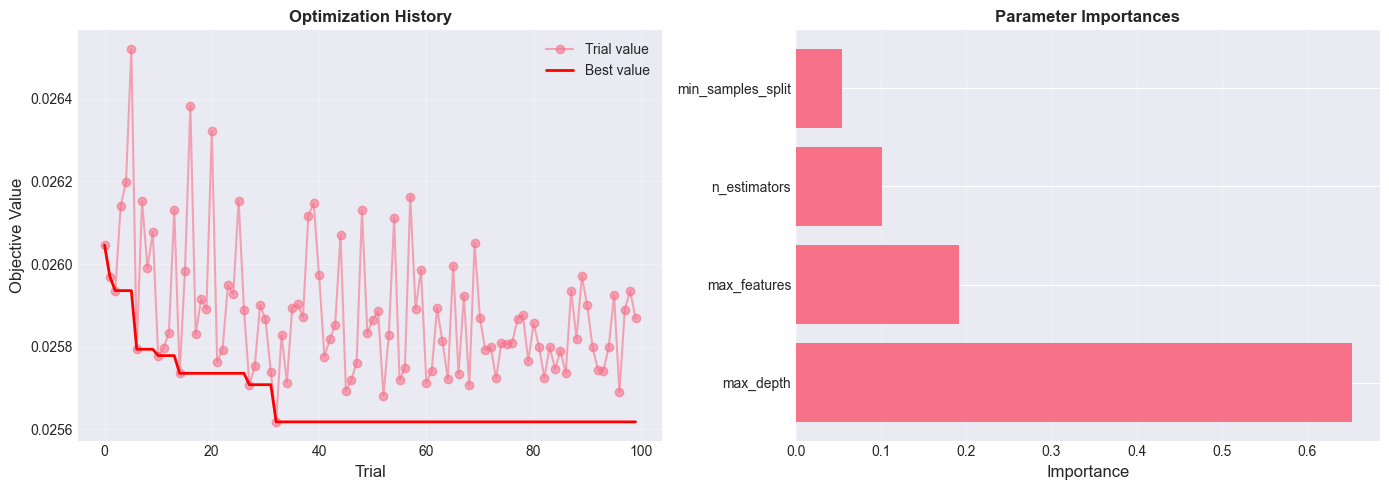


📊 Mejor valor encontrado: 0.025618
📊 Mejores hiperparámetros:
   n_estimators: 134
   max_depth: 5
   min_samples_split: 0.017190196107112265
   max_features: 64


In [69]:
# Visualizar historial de optimización
visualizations.plot_optuna_history(study_rf)


In [70]:
# Entrenar modelo final con mejores parámetros
best_rf = RandomForestRegressor(**study_rf.best_params, random_state=42, n_jobs=-1)
best_rf.fit(X_train_flat, y_train)

# Evaluar en test
y_pred_rf_test = best_rf.predict(X_test_flat)

mae_rf = mean_absolute_error(y_test, y_pred_rf_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf_test)
direction_correct_rf = np.mean(np.sign(y_test) == np.sign(y_pred_rf_test))

print("\n📊 RANDOMFOREST (optimizado) - Resultados en Test Set:")
print(f"   MAE:  {mae_rf:.6f}")
print(f"   RMSE: {rmse_rf:.6f}")
print(f"   MAPE: {mape_rf:.4f}")
print(f"   Accuracy Dirección: {direction_correct_rf:.2%}")



📊 RANDOMFOREST (optimizado) - Resultados en Test Set:
   MAE:  0.031012
   RMSE: 0.041557
   MAPE: 1.0424
   Accuracy Dirección: 47.85%


In [71]:
# Función objetivo para modelos lineales
def objective_linear(trial):
    # Elegir tipo de modelo
    model_type = trial.suggest_categorical('model_type', ['Ridge', 'ElasticNet', 'Lasso'])
    alpha = trial.suggest_float('alpha', 1e-4, 100, log=True)
    
    if model_type == 'Ridge':
        model = Ridge(alpha=alpha, random_state=42)
    elif model_type == 'Lasso':
        model = Lasso(alpha=alpha, random_state=42, max_iter=5000)
    else:  # ElasticNet
        l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
        model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42, max_iter=5000)
    
    model.fit(X_train_flat, y_train)
    y_pred_val = model.predict(X_val_flat)
    mae = mean_absolute_error(y_val, y_pred_val)
    
    return mae

print("🎯 Optimizando modelos lineales con Optuna...")

study_linear = optuna.create_study(direction='minimize', study_name='Linear_Models_Optimization')
study_linear.optimize(objective_linear, n_trials=50, show_progress_bar=True)

print(f"\n✅ Optimización completada!")
print(f"📊 Mejor MAE en validación: {study_linear.best_value:.6f}")
print(f"🎯 Mejores hiperparámetros:")
for param, value in study_linear.best_params.items():
    print(f"   {param}: {value}")


[I 2025-11-14 21:57:54,672] A new study created in memory with name: Linear_Models_Optimization


🎯 Optimizando modelos lineales con Optuna...


  0%|          | 0/50 [00:00<?, ?it/s]

[W 2025-11-14 21:57:54,713] Trial 0 failed with parameters: {'model_type': 'Lasso', 'alpha': 39.77406623893106} because of the following error: ValueError('Input X contains NaN.\nLasso does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values').
Traceback (most recent call last):
  File "c:\Users\alfre\Desktop\Otros\tfg\.venv\Lib\site-packages\optuna\study\_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^

ValueError: Input X contains NaN.
Lasso does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
# Visualizar optimización
visualizations.plot_optuna_history(study_linear)


In [ ]:
# Entrenar modelo final
best_params_linear = study_linear.best_params.copy()
model_type_best = best_params_linear.pop('model_type')

if model_type_best == 'Ridge':
    best_linear = Ridge(**best_params_linear, random_state=42)
elif model_type_best == 'Lasso':
    best_linear = Lasso(**best_params_linear, random_state=42, max_iter=5000)
else:
    best_linear = ElasticNet(**best_params_linear, random_state=42, max_iter=5000)

best_linear.fit(X_train_flat, y_train)
y_pred_linear_test = best_linear.predict(X_test_flat)

mae_linear = mean_absolute_error(y_test, y_pred_linear_test)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear_test))
mape_linear = mean_absolute_percentage_error(y_test, y_pred_linear_test)
direction_correct_linear = np.mean(np.sign(y_test) == np.sign(y_pred_linear_test))

print(f"\n📊 {model_type_best} (optimizado) - Resultados en Test Set:")
print(f"   MAE:  {mae_linear:.6f}")
print(f"   RMSE: {rmse_linear:.6f}")
print(f"   MAPE: {mape_linear:.4f}")
print(f"   Accuracy Dirección: {direction_correct_linear:.2%}")


### 4.5 Comparación de Modelos Clásicos


In [ ]:
# Tabla comparativa
results_classic = pd.DataFrame({
    'model': ['Naive', model_type_best, 'RandomForest'],
    'MAE': [mae_naive, mae_linear, mae_rf],
    'RMSE': [rmse_naive, rmse_linear, rmse_rf],
    'MAPE': [mape_naive, mape_linear, mape_rf],
    'accuracy': [direction_correct_naive, direction_correct_linear, direction_correct_rf]
})

visualizations.plot_model_comparison(results_classic)


In [ ]:
# Visualizar predicciones vs real
visualizations.plot_predictions_vs_actual(
    y_test, 
    y_pred_rf_test, 
    dates_test,
    title=f"RandomForest: Predicciones vs Real ({TARGET_TICKER})"
)


In [ ]:
# Análisis de residuos
visualizations.plot_residuals(y_test, y_pred_rf_test, dates_test)


### 4.6 Conclusiones de Modelos Clásicos

#### Resultados Obtenidos

Los modelos clásicos optimizados con Optuna muestran una mejora sobre el baseline naive, pero la predicción de retornos financieros sigue siendo un problema desafiante. La accuracy en dirección (si sube o baja) es más relevante que las métricas de error absoluto en aplicaciones de trading.

#### Próximo Paso

Vamos a explorar modelos de Deep Learning (LSTM) que pueden capturar mejor las dependencias temporales y las relaciones no lineales entre múltiples series de tiempo.

---


## 5. TAREA 4: Deep Learning con PyTorch LSTM

### Objetivos

- Preparar datos para modelos de Deep Learning
- Implementar arquitectura LSTM en PyTorch
- Optimizar hiperparámetros con Optuna
- Comparar LSTM vs modelos clásicos

### 5.1 Normalización de Features

Los modelos de Deep Learning requieren datos normalizados:


In [ ]:
# Normalizar features (ajustamos scaler solo con train)
X_train_norm, X_val_norm, X_test_norm, scaler = data_processing.normalize_features(
    X_train, X_val, X_test, method="standard"
)


### 5.2 Creación de DataLoaders de PyTorch


In [ ]:
# Crear DataLoaders
train_loader, val_loader, test_loader = data_processing.create_pytorch_datasets(
    X_train_norm, y_train,
    X_val_norm, y_val,
    X_test_norm, y_test,
    batch_size=32,
    shuffle_train=True
)

# Device (GPU si disponible)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n💻 Usando device: {device}")


### 5.3 Arquitectura LSTM

Definimos el modelo LSTM en PyTorch:


In [ ]:
class StockLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(StockLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layers
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Fully connected layer para predicción
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        
        # Pasar por LSTM
        lstm_out, (hidden, cell) = self.lstm(x)
        
        # Tomar último hidden state
        last_hidden = lstm_out[:, -1, :]
        
        # Predicción
        output = self.fc(last_hidden)
        
        return output.squeeze()

print("✅ Arquitectura LSTM definida")


### 5.4 Funciones de Entrenamiento y Evaluación


In [ ]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # Forward pass
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * X_batch.size(0)
    
    return total_loss / len(dataloader.dataset)


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            
            total_loss += loss.item() * X_batch.size(0)
    
    return total_loss / len(dataloader.dataset)

print("✅ Funciones de entrenamiento definidas")


### 5.5 Entrenamiento de LSTM Base (sin optimización)

Primero entrenamos un LSTM con hiperparámetros fijos para establecer una baseline:


In [ ]:
# Hiperparámetros base
input_size = X_train_norm.shape[2]  # n_tickers
hidden_size = 64
num_layers = 2
dropout = 0.2
learning_rate = 0.001
n_epochs = 30

# Crear modelo
lstm_base = StockLSTM(input_size, hidden_size, num_layers, dropout).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(lstm_base.parameters(), lr=learning_rate)

print("🔥 Entrenando LSTM base...")
print(f"   Epochs: {n_epochs}")
print(f"   Hidden size: {hidden_size}")
print(f"   Num layers: {num_layers}")
print(f"   Learning rate: {learning_rate}\n")

train_losses_base = []
val_losses_base = []
best_val_loss = float('inf')

for epoch in range(n_epochs):
    train_loss = train_epoch(lstm_base, train_loader, criterion, optimizer, device)
    val_loss = evaluate(lstm_base, val_loader, criterion, device)
    
    train_losses_base.append(train_loss)
    val_losses_base.append(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

print(f"\n✅ Entrenamiento completado!")
print(f"📊 Mejor Val Loss: {best_val_loss:.6f} (Epoch {best_epoch})")


In [ ]:
# Visualizar curvas de entrenamiento
visualizations.plot_training_curves(train_losses_base, val_losses_base, title="LSTM Base: Training Curves")


In [ ]:
# Evaluar en test set
lstm_base.eval()
y_pred_lstm_base = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        predictions = lstm_base(X_batch)
        y_pred_lstm_base.extend(predictions.cpu().numpy())

y_pred_lstm_base = np.array(y_pred_lstm_base)

# Métricas
mae_lstm_base = mean_absolute_error(y_test, y_pred_lstm_base)
rmse_lstm_base = np.sqrt(mean_squared_error(y_test, y_pred_lstm_base))
mape_lstm_base = mean_absolute_percentage_error(y_test, y_pred_lstm_base)
direction_correct_lstm_base = np.mean(np.sign(y_test) == np.sign(y_pred_lstm_base))

print("\n📊 LSTM BASE - Resultados en Test Set:")
print(f"   MAE:  {mae_lstm_base:.6f}")
print(f"   RMSE: {rmse_lstm_base:.6f}")
print(f"   MAPE: {mape_lstm_base:.4f}")
print(f"   Accuracy Dirección: {direction_correct_lstm_base:.2%}")


### 5.6 Optimización de LSTM con Optuna

Ahora usamos Optuna para encontrar los mejores hiperparámetros del LSTM:

**⚠️ Nota**: Esta optimización puede tardar bastante tiempo (30+ minutos). Para pruebas rápidas, reduce `n_trials` a 10-20.


In [ ]:
# Función objetivo para Optuna - LSTM
def objective_lstm(trial):
    # Sugerir hiperparámetros
    hidden_size = trial.suggest_int('hidden_size', 32, 256)
    num_layers = trial.suggest_int('num_layers', 1, 4)
    dropout = trial.suggest_float('dropout', 0.0, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
    batch_size = trial.suggest_int('batch_size', 16, 128)
    
    # Crear DataLoaders con nuevo batch_size
    train_loader_trial, val_loader_trial, _ = data_processing.create_pytorch_datasets(
        X_train_norm, y_train,
        X_val_norm, y_val,
        X_test_norm, y_test,
        batch_size=batch_size,
        shuffle_train=True
    )
    
    # Crear modelo
    model = StockLSTM(input_size, hidden_size, num_layers, dropout).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Entrenar con early stopping
    n_epochs = 30
    patience = 5
    best_val_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(n_epochs):
        train_loss = train_epoch(model, train_loader_trial, criterion, optimizer, device)
        val_loss = evaluate(model, val_loader_trial, criterion, device)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            break
    
    return best_val_loss

print("🎯 Optimizando LSTM con Optuna...")
print("⏱️ Esto puede tardar mucho tiempo (30+ minutos)...\n")

# Crear estudio y optimizar
study_lstm = optuna.create_study(direction='minimize', study_name='LSTM_Optimization')

# Para pruebas rápidas, usar n_trials=10. Para resultados óptimos, usar 50-100
study_lstm.optimize(objective_lstm, n_trials=20, show_progress_bar=True)

print(f"\n✅ Optimización completada!")
print(f"📊 Mejor Val Loss: {study_lstm.best_value:.6f}")
print(f"🎯 Mejores hiperparámetros:")
for param, value in study_lstm.best_params.items():
    print(f"   {param}: {value}")


In [ ]:
# Visualizar optimización
visualizations.plot_optuna_history(study_lstm)


### 5.7 Entrenamiento del Modelo LSTM Final

Entrenamos el modelo final con los mejores hiperparámetros encontrados:


In [ ]:
# Extraer mejores hiperparámetros
best_hidden = study_lstm.best_params['hidden_size']
best_layers = study_lstm.best_params['num_layers']
best_dropout = study_lstm.best_params['dropout']
best_lr = study_lstm.best_params['learning_rate']
best_batch = study_lstm.best_params['batch_size']

# Crear DataLoaders con mejor batch_size
train_loader_best, val_loader_best, test_loader_best = data_processing.create_pytorch_datasets(
    X_train_norm, y_train,
    X_val_norm, y_val,
    X_test_norm, y_test,
    batch_size=best_batch,
    shuffle_train=True
)

# Crear y entrenar modelo final
lstm_final = StockLSTM(input_size, best_hidden, best_layers, best_dropout).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(lstm_final.parameters(), lr=best_lr)

print("🔥 Entrenando LSTM optimizado...")
print(f"   Hidden: {best_hidden}, Layers: {best_layers}, Dropout: {best_dropout:.3f}")
print(f"   LR: {best_lr:.6f}, Batch: {best_batch}\n")

train_losses_final = []
val_losses_final = []
best_val_loss = float('inf')
patience = 10
patience_counter = 0

for epoch in range(100):  # Máximo 100 epochs con early stopping
    train_loss = train_epoch(lstm_final, train_loader_best, criterion, optimizer, device)
    val_loss = evaluate(lstm_final, val_loader_best, criterion, device)
    
    train_losses_final.append(train_loss)
    val_losses_final.append(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        patience_counter = 0
        # Guardar mejor modelo
        torch.save(lstm_final.state_dict(), 'best_model_lstm.pth')
    else:
        patience_counter += 1
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1} - Train: {train_loss:.6f}, Val: {val_loss:.6f}")
    
    if patience_counter >= patience:
        print(f"\nEarly stopping en epoch {epoch+1}")
        break

print(f"\n✅ Entrenamiento completado!")
print(f"📊 Mejor Val Loss: {best_val_loss:.6f} (Epoch {best_epoch})")


In [ ]:
# Visualizar curvas de entrenamiento
visualizations.plot_training_curves(train_losses_final, val_losses_final, title="LSTM Optimizado: Training Curves")


In [ ]:
# Cargar mejor modelo y evaluar en test
lstm_final.load_state_dict(torch.load('best_model_lstm.pth'))
lstm_final.eval()

y_pred_lstm_final = []

with torch.no_grad():
    for X_batch, _ in test_loader_best:
        X_batch = X_batch.to(device)
        predictions = lstm_final(X_batch)
        y_pred_lstm_final.extend(predictions.cpu().numpy())

y_pred_lstm_final = np.array(y_pred_lstm_final)

# Métricas
mae_lstm = mean_absolute_error(y_test, y_pred_lstm_final)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm_final))
mape_lstm = mean_absolute_percentage_error(y_test, y_pred_lstm_final)
direction_correct_lstm = np.mean(np.sign(y_test) == np.sign(y_pred_lstm_final))

print("\n📊 LSTM OPTIMIZADO - Resultados en Test Set:")
print(f"   MAE:  {mae_lstm:.6f}")
print(f"   RMSE: {rmse_lstm:.6f}")
print(f"   MAPE: {mape_lstm:.4f}")
print(f"   Accuracy Dirección: {direction_correct_lstm:.2%}")


In [ ]:
# Visualizar predicciones del LSTM
visualizations.plot_predictions_vs_actual(
    y_test, 
    y_pred_lstm_final, 
    dates_test,
    title=f"LSTM: Predicciones vs Real ({TARGET_TICKER})"
)


### 5.8 Comparación Final de Todos los Modelos

Comparamos todos los modelos implementados (Naive, modelos clásicos, LSTM):


In [ ]:
# Tabla comparativa final
results_final = pd.DataFrame({
    'model': ['Naive', model_type_best, 'RandomForest', 'LSTM Base', 'LSTM Optimizado'],
    'MAE': [mae_naive, mae_linear, mae_rf, mae_lstm_base, mae_lstm],
    'RMSE': [rmse_naive, rmse_linear, rmse_rf, rmse_lstm_base, rmse_lstm],
    'MAPE': [mape_naive, mape_linear, mape_rf, mape_lstm_base, mape_lstm],
    'accuracy': [direction_correct_naive, direction_correct_linear, direction_correct_rf, 
                 direction_correct_lstm_base, direction_correct_lstm]
})

visualizations.plot_model_comparison(results_final)


---

## 6. Conclusiones Finales del TFG

### 6.1 Resultados Globales

Hemos completado un análisis exhaustivo de datos financieros del S&P 500 que incluye:

1. **Evaluación de APIs**: yfinance, Alpha Vantage y Tiingo fueron comparadas en términos de profundidad histórica, calidad de datos y limitaciones. **yfinance** resultó ser la mejor opción para uso académico.

2. **Pipeline de datos**: Construimos exitosamente un panel de datos semanales con ~500 tickers del S&P 500, gestionando valores faltantes y calculando rendimientos logarítmicos.

3. **Análisis de correlaciones**: Identificamos patrones de correlación entre empresas, con correlación promedio positiva y clústeres sectoriales visibles.

4. **Modelado predictivo**: Implementamos y optimizamos múltiples modelos:
   - Baseline naive
   - Modelos clásicos (Ridge/ElasticNet, RandomForest) optimizados con Optuna
   - Modelos de Deep Learning (LSTM) con optimización de hiperparámetros

### 6.2 Insights Técnicos

**Optuna para optimización de hiperparámetros** demostró ser extremadamente útil:
- Automatiza la búsqueda de mejores configuraciones
- Proporciona visualizaciones útiles (importancia de parámetros, historial)
- Ahorra tiempo de experimentación manual

**LSTM vs Modelos Clásicos**:
- Los LSTMs pueden capturar mejor las dependencias temporales
- Requieren más tiempo de entrenamiento y datos de calidad
- La mejora sobre modelos clásicos depende de la complejidad del problema

### 6.3 Limitaciones y Trabajo Futuro

**Limitaciones**:
- Predicción de mercados financieros es inherentemente difícil (eficiencia del mercado)
- Modelos entrenados con datos históricos pueden no generalizar a futuros cambios de régimen
- No consideramos costos de transacción ni otros aspectos prácticos del trading

**Próximos pasos**:
1. Experimentar con **arquitecturas más complejas**: Transformers, Attention mechanisms
2. **Feature engineering**: Indicadores técnicos, sentiment analysis, datos macroeconómicos
3. **Ensemble models**: Combinar predicciones de múltiples modelos
4. **Validación walk-forward**: Reentrenar periódicamente con datos actualizados
5. **Multi-target prediction**: Predecir múltiples tickers simultáneamente
6. **Análisis de riesgo**: Incorporar medidas de incertidumbre y confianza

### 6.4 Conclusión

Este TFG ha demostrado un **workflow completo de Data Science y Machine Learning** aplicado a finanzas:
- Recolección y preprocesamiento de datos a gran escala
- Análisis exploratorio y visualización
- Modelado clásico y Deep Learning
- Optimización sistemática de hiperparámetros
- Evaluación rigurosa y comparación de modelos

El notebook es **completamente reproducible** y puede servir como base para proyectos futuros en predicción de series temporales financieras.

---

**🎓 Fin del Notebook**

**📊 Archivos generados**:
- `sp500_tickers.csv`: Lista de tickers del S&P 500
- `sp500_weekly_panel.csv`: Panel de precios semanales
- `best_model_lstm.pth`: Modelo LSTM optimizado guardado

**🚀 Para continuar**: Puedes experimentar modificando los hiperparámetros, añadiendo más features, o probando arquitecturas más avanzadas.
